# Incremental Capstone Unit 3: EDA

**Instructor:** Abishek Ganesh

**Your Name:** Kalpana  
**Your Role:** Data Scientist  
**Client:** Urban city
**Due Date:** Monday, March 10, 2026

---

## Project Brief


---



### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

In [1]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Definition & Data Loading

**The Problem:** Before training any model, we need to load and understand our data.

The dataset is `urbanpulse_311_complaints.csv` — 434,722 real NYC 311 service complaints with complaint type, status, agency, borough, dates, and free-text descriptions.

**Your Goal:** Load the data and verify its structure.

### Task: Load the Customer Data

**Your Task:** Create a function that loads the customer data and returns a DataFrame.

### Example Verification
```python
df = load_customer_data('urbanpulse_311_complaints.csv')
print(df.shape)  # Should print (434722, 11)
```

In [2]:
def load_customer_data(filepath):
    """
    Load customer data from a CSV file.
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: The loaded data
    """
    # Your code here
    return pd.read_csv(filepath)

In [3]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df = load_customer_data('urbanpulse_311_complaints.csv')

# Basic Verification
assert df is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df, pd.DataFrame), "Function should return a pandas DataFrame"
assert df.shape == (434722, 11), f"Expected shape (434722, 11), got {df.shape}"
assert 'complaint_type' in df.columns, "Missing classification target 'complaint_type'"
print("[PASS] Part 1 Tests Passed!")
print(f"\nDataset loaded: {df.shape[0]:,} customers, {df.shape[1]} columns")

[PASS] Part 1 Tests Passed!

Dataset loaded: 434,722 customers, 11 columns


In [4]:
# Take a first look at the data
df.head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
5,68173650,2026-03-01T13:18:50.000,2026-03-01T13:41:16.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,ONLINE,Closed
6,67996182,2026-02-14T04:34:09.000,2026-02-14T07:30:31.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
7,67989111,2026-02-13T13:14:39.000,2026-02-15T21:30:43.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,This complaint is a duplicate of a building-wi...,QUEENS,ONLINE,Closed
8,68284021,2026-03-10T08:15:03.000,2026-03-11T14:26:55.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
9,67918125,2026-02-09T11:41:22.000,NaN,DOHMH,Department of Health and Mental Hygiene,Non-Residential Heat,Inadequate or No Heat,The Department of Health and Mental Hygiene ha...,BRONX,ONLINE,In Progress


In [5]:
# Check the data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   unique_key              434722 non-null  int64
 1   created_date            434722 non-null  str  
 2   closed_date             384642 non-null  str  
 3   agency                  434722 non-null  str  
 4   agency_name             434722 non-null  str  
 5   complaint_type          434722 non-null  str  
 6   descriptor              431047 non-null  str  
 7   resolution_description  434722 non-null  str  
 8   borough                 434722 non-null  str  
 9   open_data_channel_type  434722 non-null  str  
 10  status                  434722 non-null  str  
dtypes: int64(1), str(10)
memory usage: 36.5 MB


In [6]:
# Check the churn distribution (class imbalance?)
print("complaint_type")
print(df['complaint_type'].value_counts(normalize=True))

complaint_type
complaint_type
Illegal Parking                   0.152187
HEAT/HOT WATER                    0.148053
Noise - Residential               0.089554
Snow or Ice                       0.063151
Blocked Driveway                  0.057324
                                    ...   
Illegal Animal Sold               0.000005
Found Property                    0.000002
Building Marshal's Office         0.000002
Institution Disposal Complaint    0.000002
Dept of Investigations            0.000002
Name: proportion, Length: 151, dtype: float64


---

## Part 2: Data Preparation and EDA

**The Problem:** Before training any models, we need to:
1. Handle missing values
2. Encode categorical variables
3. Encode Numeric variable
3. Scale numeric features (important for Logistic Regression)


**Note:** You can reference your Unit 2 capstone code for handling missing values, encoding, and scaling - the techniques are the same!

### Task 2a: Prepare Features

Create a function that:
 Steps:
    

### Task 2a: Clean the Data

`clean_data` handles duplicates and fills all missing values before any modelling step.

In [7]:
def clean_data(df):
    """
    Clean the 311 complaints data.

    Steps:
    1. Remove duplicate transactions (rows with the same unique_key).
    2. Fill missing numeric values with the column median.
    3. Fill missing categorical values with the column mode.

    Args:
        df (pd.DataFrame): Raw DataFrame from load_customer_data.

    Returns:
        pd.DataFrame: Cleaned DataFrame with no duplicates and no missing values
                      in columns that can be imputed.
    """
    cleaned = df.copy()

    # ── Step 1: Remove duplicate transactions ────────────────────────────────
    before = len(cleaned)
    cleaned = cleaned.drop_duplicates(subset='unique_key', keep='first')
    dupes_removed = before - len(cleaned)
    print(f"Step 1 — Duplicates removed : {dupes_removed:,}  "
          f"(rows remaining: {len(cleaned):,})")

    # ── Step 2: Fill missing numeric values with column median ────────────────
    # unique_key is an ID — skip it; apply median only to true numeric columns
    numeric_cols = (
        cleaned.select_dtypes(include=[np.number])
               .columns
               .difference(['unique_key'])   # exclude the identifier
               .tolist()
    )
    filled_numeric = 0
    for col in numeric_cols:
        n_missing = cleaned[col].isnull().sum()
        if n_missing > 0:
            median_val = cleaned[col].median()
            cleaned[col] = cleaned[col].fillna(median_val)
            filled_numeric += n_missing
            print(f"  Numeric  '{col}': filled {n_missing:,} nulls with median={median_val:.4f}")
    print(f"Step 2 — Numeric cells filled  : {filled_numeric:,}")

    # ── Step 3: Fill missing categorical values with column mode ──────────────
    categorical_cols = cleaned.select_dtypes(include='object').columns.tolist()
    filled_categorical = 0
    for col in categorical_cols:
        n_missing = cleaned[col].isnull().sum()
        if n_missing > 0:
            mode_val = cleaned[col].mode()[0]   # mode() returns a Series; take first
            cleaned[col] = cleaned[col].fillna(mode_val)
            filled_categorical += n_missing
            print(f"  Categorical '{col}': filled {n_missing:,} nulls with mode='{mode_val}'")
    print(f"Step 3 — Categorical cells filled: {filled_categorical:,}")

    print(f"\nCleaning complete.")
    print(f"  Original shape : {df.shape}")
    print(f"  Cleaned shape  : {cleaned.shape}")
    print(f"  Remaining nulls: {cleaned.isnull().sum().sum()}")

    return cleaned


df_clean = clean_data(df)
df_clean.head()

Step 1 — Duplicates removed : 0  (rows remaining: 434,722)
Step 2 — Numeric cells filled  : 0
  Categorical 'closed_date': filled 50,080 nulls with mode='2026-02-27T00:00:00.000'
  Categorical 'descriptor': filled 3,675 nulls with mode='ENTIRE BUILDING'
Step 3 — Categorical cells filled: 53,755

Cleaning complete.
  Original shape : (434722, 11)
  Cleaned shape  : (434722, 11)
  Remaining nulls: 0


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed


In [8]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# ============================================================

# 1. Returns a DataFrame
assert isinstance(df_clean, pd.DataFrame), "clean_data must return a DataFrame"

# 2. No duplicate unique_key values
assert df_clean['unique_key'].duplicated().sum() == 0, \
    "Duplicate unique_keys still present after cleaning"

# 3. No missing values remain in any column
remaining_nulls = df_clean.isnull().sum().sum()
assert remaining_nulls == 0, \
    f"Missing values still present after cleaning: {remaining_nulls} nulls"

# 4. Row count should be <= original (only equal if no duplicates existed)
assert len(df_clean) <= len(df), \
    "Cleaned DataFrame has more rows than the original — something went wrong"

# 5. Column count unchanged
assert df_clean.shape[1] == df.shape[1], \
    f"Column count changed: expected {df.shape[1]}, got {df_clean.shape[1]}"

print("[PASS] clean_data Tests Passed!")
print(f"\nOriginal : {df.shape[0]:,} rows | {df.isnull().sum().sum():,} total nulls")
print(f"Cleaned  : {df_clean.shape[0]:,} rows | {df_clean.isnull().sum().sum()} total nulls")

[PASS] clean_data Tests Passed!

Original : 434,722 rows | 53,755 total nulls
Cleaned  : 434,722 rows | 0 total nulls


---

## Part 1 (continued): Exploratory Data Analysis

Now that the data is loaded and cleaned, we explore its structure, distributions, and patterns before building any model.

### Task 1a: Missing Value Analysis

Identify which columns have missing data and how much.

=== Missing Value Summary ===
             Missing Count  Missing %
closed_date          50080      11.52
descriptor            3675       0.85


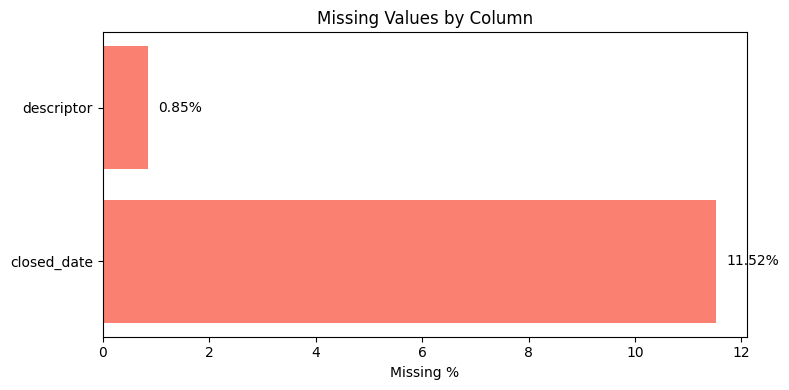

In [9]:
# --- Missing Value Summary ---
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing,
                            'Missing %': missing_pct})\
               .sort_values('Missing %', ascending=False)

print('=== Missing Value Summary ===')
print(missing_df[missing_df['Missing Count'] > 0])

# Bar chart
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
if not cols_with_missing.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(cols_with_missing.index, cols_with_missing['Missing %'], color='salmon')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    for i, v in enumerate(cols_with_missing['Missing %']):
        ax.text(v + 0.2, i, f'{v}%', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

### Task 1b: Distribution of Key Categorical Variables

Which complaint types, boroughs, and agencies dominate the dataset?

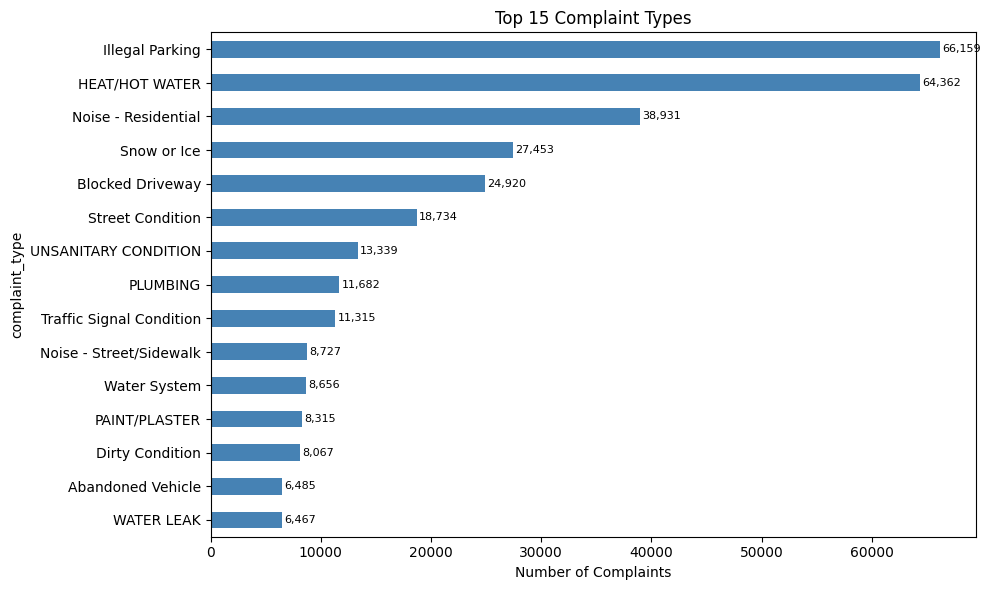


Total unique complaint types: 151


In [10]:
# --- Top 15 Complaint Types ---
top15 = df['complaint_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Number of Complaints')
ax.set_title('Top 15 Complaint Types')
for i, v in enumerate(top15.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f'\nTotal unique complaint types: {df["complaint_type"].nunique()}')

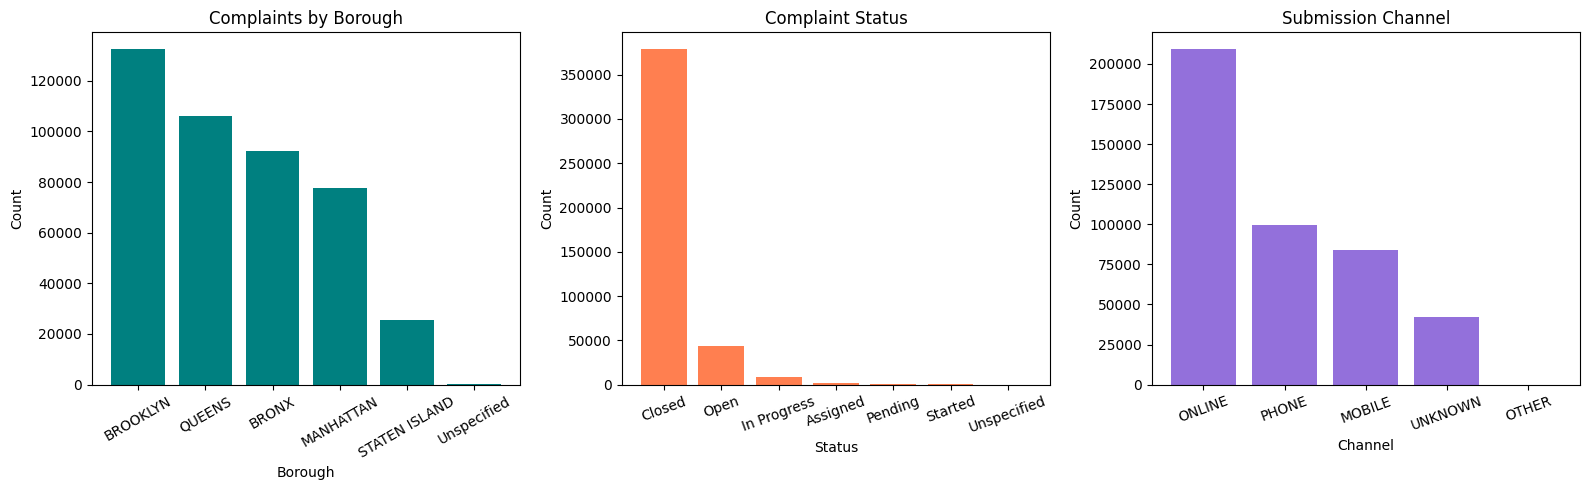

Borough:
 borough
BROOKLYN         132549
QUEENS           106203
BRONX             92354
MANHATTAN         77788
STATEN ISLAND     25487
Unspecified         341
Name: count, dtype: int64

Status:
 status
Closed         378879
Open            43197
In Progress      8469
Assigned         2209
Pending          1099
Started           866
Unspecified         3
Name: count, dtype: int64

Channel:
 open_data_channel_type
ONLINE     209252
PHONE       99451
MOBILE      83812
UNKNOWN     42205
OTHER           2
Name: count, dtype: int64


In [11]:
# --- Borough / Status / Channel ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

borough_counts = df['borough'].value_counts()
axes[0].bar(borough_counts.index, borough_counts.values, color='teal')
axes[0].set_title('Complaints by Borough')
axes[0].set_xlabel('Borough'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

status_counts = df['status'].value_counts()
axes[1].bar(status_counts.index, status_counts.values, color='coral')
axes[1].set_title('Complaint Status')
axes[1].set_xlabel('Status'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

channel_counts = df['open_data_channel_type'].value_counts()
axes[2].bar(channel_counts.index, channel_counts.values, color='mediumpurple')
axes[2].set_title('Submission Channel')
axes[2].set_xlabel('Channel'); axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Borough:\n', borough_counts)
print('\nStatus:\n', status_counts)
print('\nChannel:\n', channel_counts)

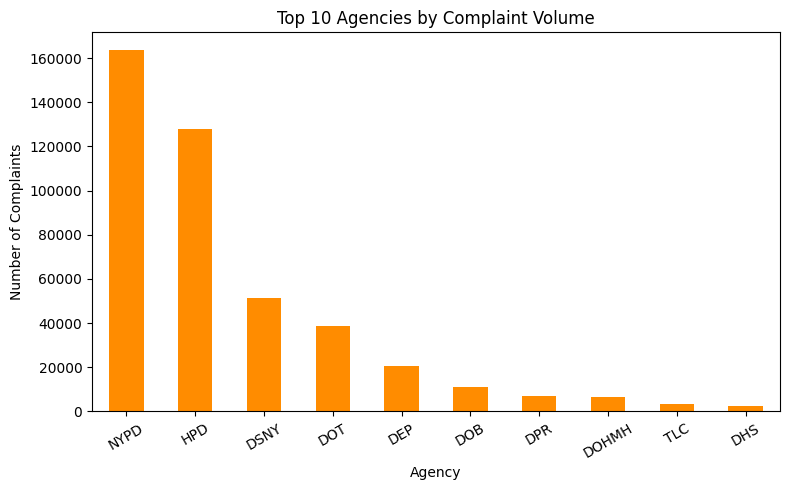


Top 10 agencies:
 agency
NYPD     163498
HPD      127848
DSNY      51482
DOT       38642
DEP       20719
DOB       11126
DPR        7178
DOHMH      6455
TLC        3228
DHS        2279
Name: count, dtype: int64


In [12]:
# --- Top 10 Agencies ---
top_agencies = df['agency'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_agencies.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Top 10 Agencies by Complaint Volume')
ax.set_xlabel('Agency'); ax.set_ylabel('Number of Complaints')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\nTop 10 agencies:\n', top_agencies)

### Task 1c: Date & Time Analysis

Parse timestamps, compute resolution time, and look for temporal patterns.

In [13]:
# --- Parse Dates and Engineer Temporal Features ---
df_eda = df_clean.copy()

df_eda['created_date'] = pd.to_datetime(df_eda['created_date'], errors='coerce')
df_eda['closed_date']  = pd.to_datetime(df_eda['closed_date'],  errors='coerce')

df_eda['resolution_hours'] = (
    (df_eda['closed_date'] - df_eda['created_date'])
    .dt.total_seconds() / 3600
)
df_eda['hour_of_day'] = df_eda['created_date'].dt.hour
df_eda['day_of_week'] = df_eda['created_date'].dt.day_name()
df_eda['month']       = df_eda['created_date'].dt.month
df_eda['is_weekend']  = df_eda['created_date'].dt.dayofweek >= 5

print('Temporal features added:')
print(df_eda[['created_date','closed_date','resolution_hours',
              'hour_of_day','day_of_week','is_weekend']].head())
print('\nResolution time stats (hours):')
print(df_eda['resolution_hours'].describe().round(2))

Temporal features added:
         created_date         closed_date  resolution_hours  hour_of_day  \
0 2026-02-06 14:57:28 2026-02-07 21:24:52         30.456667           14   
1 2026-03-04 10:40:04 2026-03-06 16:05:24         53.422222           10   
2 2026-03-12 11:26:42 2026-03-12 12:34:47          1.134722           11   
3 2026-02-06 23:51:20 2026-02-09 12:21:00         60.494444           23   
4 2026-02-03 10:01:52 2026-02-03 10:55:36          0.895556           10   

  day_of_week  is_weekend  
0      Friday       False  
1   Wednesday       False  
2    Thursday       False  
3      Friday       False  
4     Tuesday       False  

Resolution time stats (hours):
count    434722.00
mean         42.75
std         147.71
min        -435.06
25%           0.78
50%           5.54
75%          54.86
max        7274.13
Name: resolution_hours, dtype: float64


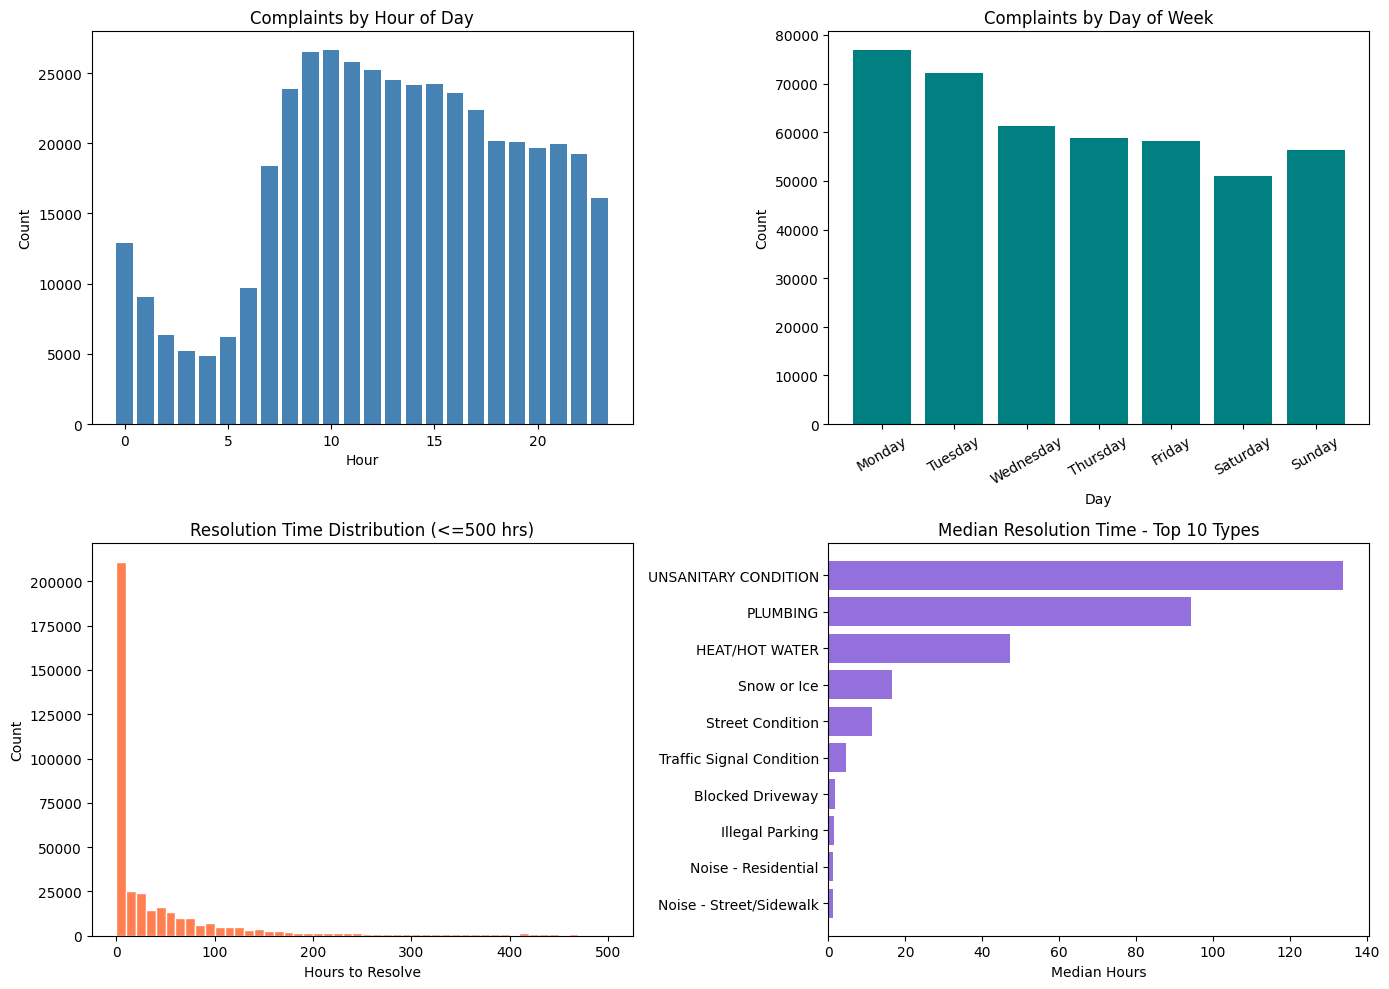

In [14]:
# --- Temporal Pattern Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. By hour of day
hour_counts = df_eda['hour_of_day'].value_counts().sort_index()
axes[0,0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[0,0].set_title('Complaints by Hour of Day')
axes[0,0].set_xlabel('Hour'); axes[0,0].set_ylabel('Count')

# 2. By day of week
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts  = df_eda['day_of_week'].value_counts().reindex(day_order)
axes[0,1].bar(day_counts.index, day_counts.values, color='teal')
axes[0,1].set_title('Complaints by Day of Week')
axes[0,1].set_xlabel('Day'); axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Resolution time histogram (cap at 500 hrs)
res_valid = df_eda['resolution_hours'].dropna()
res_valid = res_valid[(res_valid >= 0) & (res_valid <= 500)]
axes[1,0].hist(res_valid, bins=50, color='coral', edgecolor='white')
axes[1,0].set_title('Resolution Time Distribution (<=500 hrs)')
axes[1,0].set_xlabel('Hours to Resolve'); axes[1,0].set_ylabel('Count')

# 4. Median resolution time by top 10 types
top10_types = df['complaint_type'].value_counts().head(10).index
median_res  = (
    df_eda[df_eda['complaint_type'].isin(top10_types)]
    .groupby('complaint_type')['resolution_hours']
    .median().sort_values()
)
axes[1,1].barh(median_res.index, median_res.values, color='mediumpurple')
axes[1,1].set_title('Median Resolution Time - Top 10 Types')
axes[1,1].set_xlabel('Median Hours')

plt.tight_layout()
plt.show()

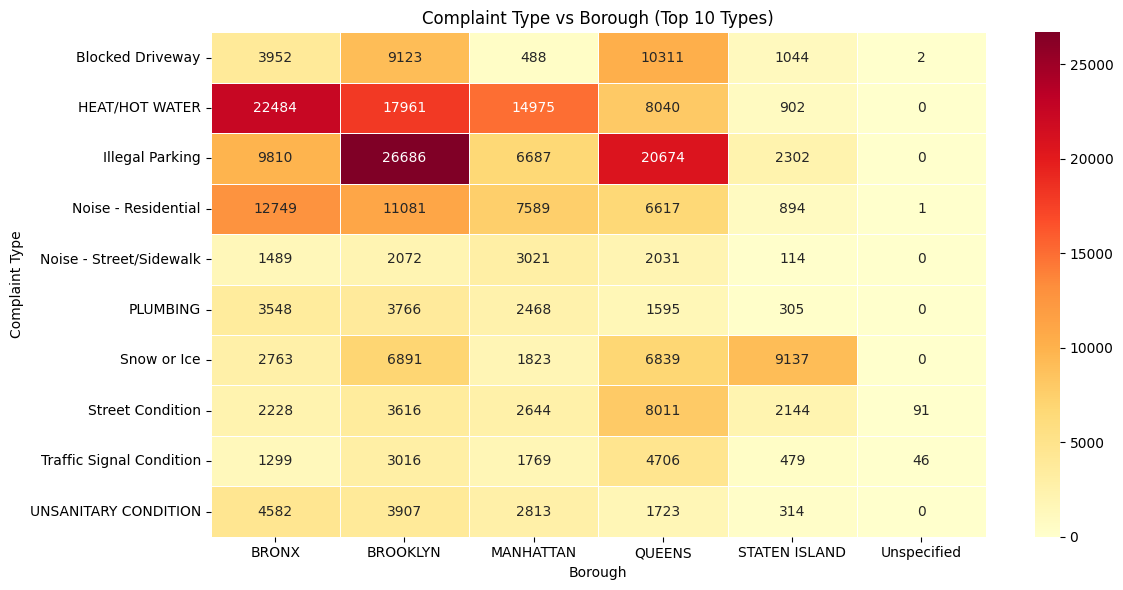

In [15]:
# --- Heatmap: Complaint Type vs Borough (top 10 types) ---
top10_types = df['complaint_type'].value_counts().head(10).index
pivot = (
    df[df['complaint_type'].isin(top10_types)]
    .groupby(['complaint_type', 'borough'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Complaint Type vs Borough (Top 10 Types)')
ax.set_xlabel('Borough'); ax.set_ylabel('Complaint Type')
plt.tight_layout()
plt.show()

---

## Part 2: Data Preparation

Steps:
1. Engineer features from cleaned data (dates → numbers)
2. Group rare complaint types into 'Other'
3. One-hot encode categoricals
4. Train / test split (stratified)
5. Scale numeric features with `StandardScaler`

### Task 2b: Prepare Features

`prepare_features` builds the final feature matrix `X` and target `y`.

In [16]:
# ── Shared descriptor rules — used by both prepare_features and
#    prepare_ml_dataframe.  Add/remove categories here in one place. ──────
DESCRIPTOR_RULES = [
    ('Noise',             ['LOUD','NOISE','BANGING','POUNDING','HORN',
                           'MUSIC','ALARM','BARKING','TELEVISION',
                           'PARTY','SHRIEKING','TALKING','CAR/TRUCK']),
    ('Heat_HotWater',     ['ENTIRE BUILDING','APARTMENT ONLY','RADIATOR',
                           'BOILER','NO HEAT','INADEQUATE','HEAT',
                           'HOT WATER','STEAM']),
    ('Plumbing_Water',    ['WATER SUPPLY','BASIN','SINK','BATHTUB',
                           'SHOWER','TOILET','LEAK','NO WATER',
                           'HYDRANT','SEWER','DIRTY WATER','SEWAGE',
                           'DRAIN','DAMP','SLOW LEAK','HEAVY FLOW',
                           'WATER METER','CATCH BASIN','WATER MAIN',
                           'PLUMBING']),
    ('Parking_Traffic',   ['PARKING','DOUBLE PARKED','LICENSE PLATE',
                           'BIKE LANE','BUS LAYOVER','DERELICT',
                           'DRIVEWAY','SIGNAL','CONE','CROSSWALK',
                           'BLOCKED HYDRANT','PEDESTRIAN','TRAFFIC',
                           'VEHICLE','WITH LICENSE']),
    ('Building_Structure',['CEILING','WALL','FLOOR','DOOR','WINDOW',
                           'CABINET','WIRING','OUTLET','INTERCOM',
                           'VENTILATION','ELECTRIC','REFRIGERATOR',
                           'COOKING GAS','SMOKE','CARBON MONOXIDE',
                           'LIGHTING','POWER','PAINT','PLASTER',
                           'MOLD','STRUCTURAL','BELL/BUZZER',
                           'GARBAGE/RECYCLING STORAGE',
                           'ILLEGAL CONVERSION']),
    ('Street_Sidewalk',   ['POTHOLE','SIDEWALK','ROADWAY','CAVE-IN',
                           'STREET LIGHT','SNOW','ICE','FAILED STREET',
                           'ROUGH','BROKEN SIDEWALK','ROAD',
                           'STREET REPAIR','PITTED']),
    ('Sanitation_Waste',  ['TRASH','GARBAGE','RECYCLING','GRAFFITI',
                           'DOG WASTE','ILLEGAL DUMP','DIRTY',
                           'LITTER','UNSANITARY','WASTE']),
    ('Pest_Animal',       ['RAT','PEST','MICE','MOUSE','ROACH',
                           'BED BUG','ANIMAL','INSECT','RODENT',
                           'MOSQUITO','BIRD','DOG']),
    ('Access_Elevator',   ['NO ACCESS','PARTIAL ACCESS','ACCESS','ELEVATOR']),
    ('Tree_Vegetation',   ['BRANCH','TREE','LIMB','FALLEN','TRUNK','ROOT']),
]

print(f"DESCRIPTOR_RULES loaded: {len(DESCRIPTOR_RULES)} categories")
for cat, kws in DESCRIPTOR_RULES:
    print(f"  {cat:20s} ({len(kws)} keywords)")


DESCRIPTOR_RULES loaded: 10 categories
  Noise                (13 keywords)
  Heat_HotWater        (9 keywords)
  Plumbing_Water       (20 keywords)
  Parking_Traffic      (15 keywords)
  Building_Structure   (24 keywords)
  Street_Sidewalk      (13 keywords)
  Sanitation_Waste     (10 keywords)
  Pest_Animal          (12 keywords)
  Access_Elevator      (4 keywords)
  Tree_Vegetation      (6 keywords)


In [17]:
def prepare_features(df, top_n_complaint_types=10, scaler=None):
    """
    Engineer, encode, and scale features from the cleaned 311 DataFrame.

    Steps:
      1. Drop non-informative columns (unique_key, agency_name,
         resolution_description).
      2. Parse datetime columns; compute resolution_hours; drop date cols.
      3. Extract hour_of_day, day_of_week, month, is_weekend.
      4. Fill any remaining numeric nulls with median.
      5. Categorize descriptor via _map_descriptor (uses DESCRIPTOR_RULES).
      6. Group rare complaint_type values (outside top_n) into 'Other'.
      7. One-hot encode all categorical columns.
      8. Scale numeric features using StandardScaler.

    Args:
        df (pd.DataFrame):            Cleaned DataFrame from clean_data().
        top_n_complaint_types (int):  Keep this many complaint types. Default 10.
        scaler (StandardScaler|None): Fitted scaler to reuse, or None.

    Returns:
        X (pd.DataFrame), y (pd.Series), scaler (StandardScaler)
    """

    # ── Nested helper: looks up DESCRIPTOR_RULES (module-level) ──────
    def _map_descriptor(desc):
        if not isinstance(desc, str):
            return 'Other'
        d = desc.upper()
        for category, keywords in DESCRIPTOR_RULES:
            if any(k in d for k in keywords):
                return category
        return 'Other'

    # ─────────────────────────────────────────────────────────────────
    data = df.copy()

    # ── 1. Drop non-informative columns ──────────────────────────────
    data.drop(columns=['unique_key', 'agency_name',
                       'resolution_description'], inplace=True)

    # ── 2. Parse dates & resolution time ─────────────────────────────
    data['created_date'] = pd.to_datetime(data['created_date'], errors='coerce')
    data['closed_date']  = pd.to_datetime(data['closed_date'],  errors='coerce')
    data['resolution_hours'] = (
        (data['closed_date'] - data['created_date'])
        .dt.total_seconds() / 3600
    )
    data.loc[
        (data['resolution_hours'] < 0) | (data['resolution_hours'] > 720),
        'resolution_hours'
    ] = np.nan

    # ── 3. Temporal features ──────────────────────────────────────────
    data['hour_of_day'] = data['created_date'].dt.hour
    data['day_of_week'] = data['created_date'].dt.dayofweek
    data['month']       = data['created_date'].dt.month
    data['is_weekend']  = (data['day_of_week'] >= 5).astype(int)
    data.drop(columns=['created_date', 'closed_date'], inplace=True)

    # ── 4. Fill remaining numeric nulls with median ───────────────────
    for col in data.select_dtypes(include=[np.number]).columns:
        if data[col].isnull().any():
            data[col].fillna(data[col].median(), inplace=True)

    # ── 5. Categorize descriptor (742 → 10 categories) ────────────────
    data['descriptor'] = data['descriptor'].apply(_map_descriptor)
    print("Descriptor categories:")
    print(data['descriptor'].value_counts())

    # ── 6. Group rare complaint types into 'Other' ────────────────────
    top_types = (data['complaint_type'].value_counts()
                     .head(top_n_complaint_types).index)
    data['complaint_type'] = data['complaint_type'].apply(
        lambda x: x if x in top_types else 'Other'
    )

    # ── 7. One-hot encode all categoricals ───────────────────────────
    y        = data['complaint_type'].copy()
    cat_cols = data.select_dtypes(include='object').columns.tolist()
    X        = pd.get_dummies(data, columns=cat_cols, drop_first=True)

    # ── 8. Scale numeric features ────────────────────────────────────
    numeric_cols = ['resolution_hours', 'hour_of_day',
                    'day_of_week', 'month', 'is_weekend']
    if scaler is None:
        scaler = StandardScaler()
        X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
        print(f"\nStep 8 — New scaler fitted.")
    else:
        X[numeric_cols] = scaler.transform(X[numeric_cols])
        print(f"\nStep 8 — Existing scaler applied.")
    print(f"  Scaled : {numeric_cols}")
    print(f"  Mean~0 : {scaler.mean_.round(3)}")
    print(f"  Std~1  : {scaler.scale_.round(3)}")

    return X, y, scaler


# ── Run on full cleaned dataset ───────────────────────────────────────────
X, y, fitted_scaler = prepare_features(df_clean)
print(f'\nFeature matrix : {X.shape}')
print(f'Target         : {y.shape}')
print(f'\nClass distribution:\n{y.value_counts()}')
print(f'\nAll {len(X.columns)} feature columns:\n{X.columns.tolist()}')


Descriptor categories:
descriptor
Heat_HotWater         71352
Street_Sidewalk       63249
Noise                 62275
Parking_Traffic       53798
Plumbing_Water        48007
Other                 42228
Building_Structure    41236
Access_Elevator       24939
Sanitation_Waste      13380
Pest_Animal            9333
Tree_Vegetation        4925
Name: count, dtype: int64

Step 8 — New scaler fitted.
  Scaled : ['resolution_hours', 'hour_of_day', 'day_of_week', 'month', 'is_weekend']
  Mean~0 : [59.599 13.078  2.754  2.345  0.247]
  Std~1  : [115.467   5.955   2.027   0.475   0.431]

Feature matrix : (434722, 53)
Target         : (434722,)

Class distribution:
complaint_type
Other                       149100
Illegal Parking              66159
HEAT/HOT WATER               64362
Noise - Residential          38931
Snow or Ice                  27453
Blocked Driveway             24920
Street Condition             18734
UNSANITARY CONDITION         13339
PLUMBING                     11682
Traffic 

In [18]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 53 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   resolution_hours                         405461 non-null  float64
 1   hour_of_day                              434722 non-null  float64
 2   day_of_week                              434722 non-null  float64
 3   month                                    434722 non-null  float64
 4   is_weekend                               434722 non-null  float64
 5   agency_DEP                               434722 non-null  bool   
 6   agency_DHS                               434722 non-null  bool   
 7   agency_DOB                               434722 non-null  bool   
 8   agency_DOE                               434722 non-null  bool   
 9   agency_DOHMH                             434722 non-null  bool   
 10  agency_DOT                               43

In [19]:
X.head(20)

,resolution_hours,hour_of_day,day_of_week,month,is_weekend,agency_DEP,agency_DHS,agency_DOB,agency_DOE,agency_DOHMH,agency_DOT,agency_DPR,agency_DSNY,agency_HPD,agency_NYPD,agency_OOS,agency_OTI,agency_TLC,complaint_type_HEAT/HOT WATER,complaint_type_Illegal Parking,complaint_type_Noise - Residential,complaint_type_Noise - Street/Sidewalk,complaint_type_Other,complaint_type_PLUMBING,complaint_type_Snow or Ice,complaint_type_Street Condition,complaint_type_Traffic Signal Condition,complaint_type_UNSANITARY CONDITION,descriptor_Building_Structure,descriptor_Heat_HotWater,descriptor_Noise,descriptor_Other,descriptor_Parking_Traffic,descriptor_Pest_Animal,descriptor_Plumbing_Water,descriptor_Sanitation_Waste,descriptor_Street_Sidewalk,descriptor_Tree_Vegetation,borough_BROOKLYN,borough_MANHATTAN,borough_QUEENS,borough_STATEN ISLAND,borough_Unspecified,open_data_channel_type_ONLINE,open_data_channel_type_OTHER,open_data_channel_type_PHONE,open_data_channel_type_UNKNOWN,status_Closed,status_In Progress,status_Open,status_Pending,status_Started,status_Unspecified
0,-0.252383,0.154785,0.614842,-0.725121,-0.572851,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False
1,-0.053491,-0.516958,-0.371959,1.379080,-0.572851,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,-0.506324,-0.349022,0.121442,1.379080,-0.572851,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,0.007758,1.666208,0.614842,-0.725121,-0.572851,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False
4,-0.508395,-0.516958,-0.865359,-0.725121,-0.572851,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False
5,-0.512913,-0.013151,1.601642,1.379080,1.745656,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False
6,-0.490694,-1.524573,1.108242,-0.725121,1.745656,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False
7,-0.028847,-0.013151,0.614842,-0.725121,-0.572851,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
8,-0.254625,-0.852830,-0.865359,1.379080,-0.572851,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,Fa

---

## Part 2d: Full ML Pipeline — `prepare_ml_dataframe`

A single function that runs every preparation step end-to-end:
clean → engineer → encode → scale → split.
Call this instead of running each step separately.

In [20]:
def prepare_ml_dataframe(df, top_n_complaint_types=10, test_size=0.2,
                         random_state=42):
    """
    Full end-to-end ML preparation pipeline for the 311 complaints dataset.

    Steps 1-3  : Clean (dedup, fill numeric median, fill categorical mode).
    Step  4    : Drop non-informative columns.
    Step  5    : Parse dates → resolution_hours.
    Step  6    : Extract temporal features.
    Step  7    : Fill remaining numeric nulls.
    Step  8    : Categorize descriptor using DESCRIPTOR_RULES (module-level).
    Step  9    : Group rare complaint types → 'Other'.
    Step  10   : One-hot encode all categoricals.
    Step  11   : Stratified train / test split.
    Step  12   : Scale numeric features (fit on train only).

    Returns:
        X_train, X_test, y_train, y_test, scaler, feature_names
    """

    data   = df.copy()
    before = len(data)
    data   = data.drop_duplicates(subset='unique_key', keep='first')
    print(f"  Duplicates removed : {before - len(data):,}")
    for col in data.select_dtypes(include=[np.number]).columns.difference(['unique_key']):
        if data[col].isnull().any():
            data[col].fillna(data[col].median(), inplace=True)
    for col in data.select_dtypes(include='object').columns:
        if data[col].isnull().any():
            data[col].fillna(data[col].mode()[0], inplace=True)
    print(f"  Remaining nulls    : {data.isnull().sum().sum()}")

    data.drop(columns=['unique_key', 'agency_name',
                       'resolution_description'], inplace=True)

    data['created_date'] = pd.to_datetime(data['created_date'], errors='coerce')
    data['closed_date']  = pd.to_datetime(data['closed_date'],  errors='coerce')
    data['resolution_hours'] = (
        (data['closed_date'] - data['created_date'])
        .dt.total_seconds() / 3600
    )
    data.loc[
        (data['resolution_hours'] < 0) | (data['resolution_hours'] > 720),
        'resolution_hours'
    ] = np.nan
    data.drop(columns=['created_date', 'closed_date'], inplace=True)

    tmp                 = pd.to_datetime(df['created_date'], errors='coerce')
    data['hour_of_day'] = tmp.dt.hour
    data['day_of_week'] = tmp.dt.dayofweek
    data['month']       = tmp.dt.month
    data['is_weekend']  = (tmp.dt.dayofweek >= 5).astype(int)

    numeric_cols = ['resolution_hours','hour_of_day',
                    'day_of_week','month','is_weekend']
    for col in numeric_cols:
        if data[col].isnull().any():
            data[col].fillna(data[col].median(), inplace=True)

    # ── Step 8: Categorize descriptor (uses module-level DESCRIPTOR_RULES)
    data['descriptor'] = data['descriptor'].apply(
        lambda d: next(
            (cat for cat, kws in DESCRIPTOR_RULES
             if isinstance(d, str) and any(k in d.upper() for k in kws)),
            'Other'
        )
    )
    print(data['descriptor'].value_counts().to_string())

    top_types = (data['complaint_type'].value_counts()
                     .head(top_n_complaint_types).index)
    data['complaint_type'] = data['complaint_type'].apply(
        lambda x: x if x in top_types else 'Other'
    )

    y        = data['complaint_type'].copy()
    cat_cols = data.select_dtypes(include='object').columns.tolist()
    X        = pd.get_dummies(data, columns=cat_cols, drop_first=True)
    print(f"  Shape : {X.shape}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f"  Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

    scaler = StandardScaler()
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])
    print(f"  Mean~0 : {X_train[numeric_cols].mean().round(3).values}")
    print(f"  Std~1  : {X_train[numeric_cols].std().round(3).values}")

    print("\n✓ Pipeline complete.")
    print(f"  X_train {X_train.shape}  |  X_test {X_test.shape}")

    return X_train, X_test, y_train, y_test, scaler, X_train.columns.tolist()


X_train, X_test, y_train, y_test, scaler, feature_names = \
    prepare_ml_dataframe(df)

print(f"\n=== Final ML-ready datasets ===")
print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"\nFeatures ({len(feature_names)}):")
for i, n in enumerate(feature_names, 1):
    print(f"  {i:2d}. {n}")


  Duplicates removed : 0
  Remaining nulls    : 53755
descriptor
Heat_HotWater         67677
Street_Sidewalk       63249
Noise                 62275
Parking_Traffic       53798
Plumbing_Water        48007
Other                 45903
Building_Structure    41236
Access_Elevator       24939
Sanitation_Waste      13380
Pest_Animal            9333
Tree_Vegetation        4925
  Shape : (434722, 53)
  Train : 347,777  |  Test : 86,945
  Mean~0 : [ 0.  0. -0.  0.  0.]
  Std~1  : [1. 1. 1. 1. 1.]

✓ Pipeline complete.
  X_train (347777, 53)  |  X_test (86945, 53)

=== Final ML-ready datasets ===
X_train : (347777, 53)  |  X_test : (86945, 53)
y_train : (347777,)  |  y_test : (86945,)

Features (53):
   1. resolution_hours
   2. hour_of_day
   3. day_of_week
   4. month
   5. is_weekend
   6. agency_DEP
   7. agency_DHS
   8. agency_DOB
   9. agency_DOE
  10. agency_DOHMH
  11. agency_DOT
  12. agency_DPR
  13. agency_DSNY
  14. agency_HPD
  15. agency_NYPD
  16. agency_OOS
  17. agency_OTI
  18

---

## Final Summary

Overview of every dataset and artifact produced by `prepare_ml_dataframe`.

In [21]:
# ════════════════════════════════════════════════════════════════════
#  FINAL SUMMARY — prepare_ml_dataframe output
# ════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  FINAL SUMMARY: prepare_ml_dataframe")
print("=" * 60)

# ── Dataset shapes ────────────────────────────────────────────────
print("\n📦 Dataset Shapes")
print(f"  {'X_train':<20} {str(X_train.shape)}")
print(f"  {'X_test':<20} {str(X_test.shape)}")
print(f"  {'y_train':<20} {str(y_train.shape)}")
print(f"  {'y_test':<20} {str(y_test.shape)}")
print(f"  {'Train/Test split':<20} "
      f"{len(X_train):,} / {len(X_test):,} "
      f"({len(X_train)/len(X_train.index.append(X_test.index))*100:.0f}% / "
      f"{len(X_test)/len(X_train.index.append(X_test.index))*100:.0f}%)")

# ── Feature groups ────────────────────────────────────────────────
print("\n📐 Feature Columns by Group")
groups = {
    'Numeric (scaled)' : [c for c in feature_names
                          if c in ['resolution_hours','hour_of_day',
                                   'day_of_week','month','is_weekend']],
    'Agency'           : [c for c in feature_names if c.startswith('agency_')],
    'Descriptor'       : [c for c in feature_names if c.startswith('descriptor_')],
    'Borough'          : [c for c in feature_names if c.startswith('borough_')],
    'Channel'          : [c for c in feature_names if c.startswith('open_data')],
    'Status'           : [c for c in feature_names if c.startswith('status_')],
    'Complaint Type'   : [c for c in feature_names if c.startswith('complaint_type_')],
}
for grp, cols in groups.items():
    print(f"  {grp:<20} {len(cols):2d} cols  {cols}")

print(f"\n  {'TOTAL':<20} {len(feature_names):2d} cols")

# ── Target class distribution ─────────────────────────────────────
print("\n🎯 Target Class Distribution (y_train)")
train_dist = y_train.value_counts()
total      = len(y_train)
for label, count in train_dist.items():
    bar = '█' * int(count / total * 40)
    print(f"  {label:<35} {count:6,}  ({count/total*100:5.1f}%)  {bar}")

# ── Scaler stats ──────────────────────────────────────────────────
print("\n⚖️  StandardScaler (fitted on X_train)")
numeric_cols = ['resolution_hours','hour_of_day','day_of_week','month','is_weekend']
print(f"  {'Column':<20} {'Mean':>10} {'Std':>10}")
print(f"  {'-'*40}")
for col, mean, std in zip(numeric_cols, scaler.mean_, scaler.scale_):
    print(f"  {col:<20} {mean:>10.3f} {std:>10.3f}")

# ── Descriptor categories ─────────────────────────────────────────
print("\n🏷️  Descriptor Categories (DESCRIPTOR_RULES)")
for cat, kws in DESCRIPTOR_RULES:
    print(f"  {cat:<22} ({len(kws)} keywords)")

print("\n" + "=" * 60)
print("  ✓ Ready for model training")
print("=" * 60)


  FINAL SUMMARY: prepare_ml_dataframe

📦 Dataset Shapes
  X_train              (347777, 53)
  X_test               (86945, 53)
  y_train              (347777,)
  y_test               (86945,)
  Train/Test split     347,777 / 86,945 (80% / 20%)

📐 Feature Columns by Group
  Numeric (scaled)      5 cols  ['resolution_hours', 'hour_of_day', 'day_of_week', 'month', 'is_weekend']
  Agency               13 cols  ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD', 'agency_OOS', 'agency_OTI', 'agency_TLC']
  Descriptor           10 cols  ['descriptor_Building_Structure', 'descriptor_Heat_HotWater', 'descriptor_Noise', 'descriptor_Other', 'descriptor_Parking_Traffic', 'descriptor_Pest_Animal', 'descriptor_Plumbing_Water', 'descriptor_Sanitation_Waste', 'descriptor_Street_Sidewalk', 'descriptor_Tree_Vegetation']
  Borough               5 cols  ['borough_BROOKLYN', 'borough_MANHATTAN', 'borough_QUEENS', '